In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [68]:
!pip install mlxtend

In [69]:
df = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\Iris.csv")

In [70]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [71]:
df = df.iloc[:,1:]

In [72]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
encoder = LabelEncoder()

In [75]:
df['Species'] = encoder.fit_transform(df['Species'])

In [76]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [77]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [78]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

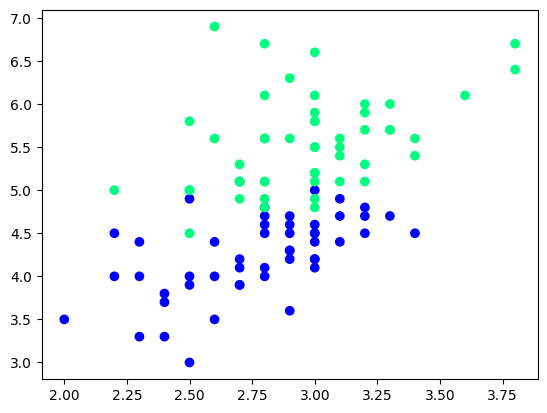

In [80]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [81]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
64,2.9,3.6,1
52,3.1,4.9,1
76,2.8,4.8,1
72,2.5,4.9,1
63,2.9,4.7,1
50,3.2,4.7,1
89,2.5,4.0,1
81,2.4,3.7,1
92,2.6,4.0,1
103,2.9,5.6,2


In [82]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [83]:
df_train

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
104,3.0,5.8,2
100,3.3,6.0,2
143,3.2,5.9,2
132,2.8,5.6,2
83,2.7,5.1,1
69,2.5,3.9,1
118,2.6,6.9,2
129,3.0,5.8,2
78,2.9,4.5,1


In [84]:
df_val

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
66,3.0,4.5,1
59,2.7,3.9,1
67,2.7,4.1,1
144,3.3,5.7,2


In [85]:
df_test

,SepalWidthCm,PetalLengthCm,Species
87,2.3,4.4,1
99,2.8,4.1,1
128,2.8,5.6,2
73,2.8,4.7,1
93,2.3,3.3,1


In [86]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [87]:
y_test

array([1, 1, 1, 1, 2])

# Case 1 - Bagging

In [88]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
83,2.7,5.1,1
129,3.0,5.8,2
143,3.2,5.9,2
72,2.5,4.9,1
100,3.3,6.0,2
118,2.6,6.9,2
132,2.8,5.6,2
143,3.2,5.9,2


In [89]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [90]:
dt_bag1 = DecisionTreeClassifier()

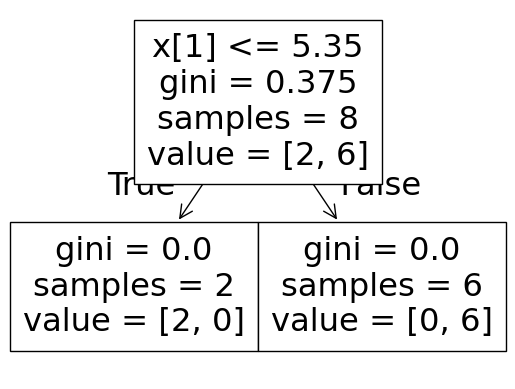

1.0


C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


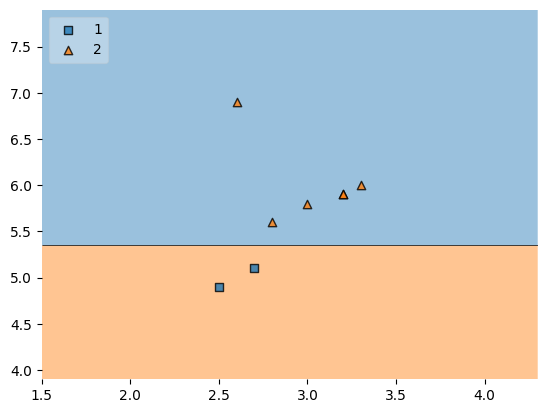

In [91]:
evaluate(dt_bag1,X,y)

In [92]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
100,3.3,6.0,2
104,3.0,5.8,2
129,3.0,5.8,2
69,2.5,3.9,1
78,2.9,4.5,1
104,3.0,5.8,2
129,3.0,5.8,2
78,2.9,4.5,1


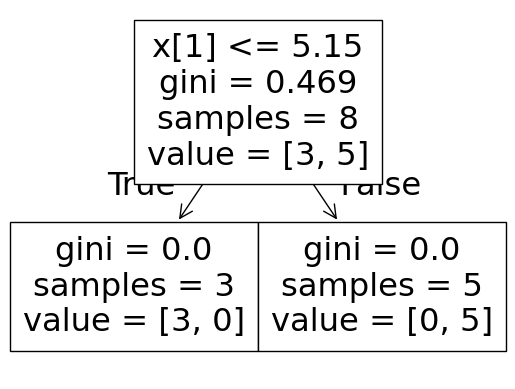

C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


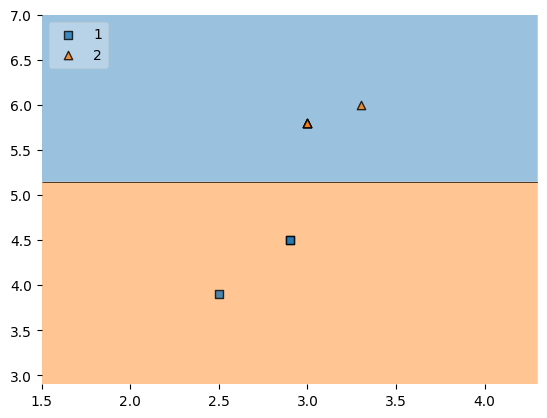

In [93]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [94]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
78,2.9,4.5,1
143,3.2,5.9,2
100,3.3,6.0,2
132,2.8,5.6,2
72,2.5,4.9,1
78,2.9,4.5,1
143,3.2,5.9,2


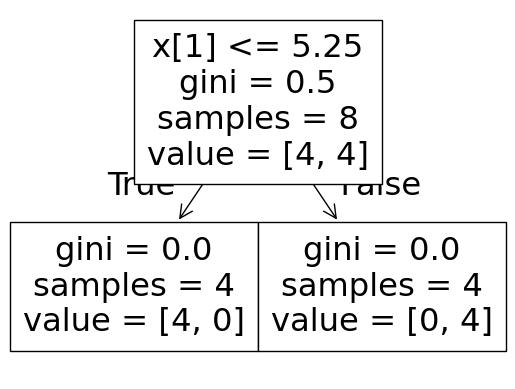

1.0


C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


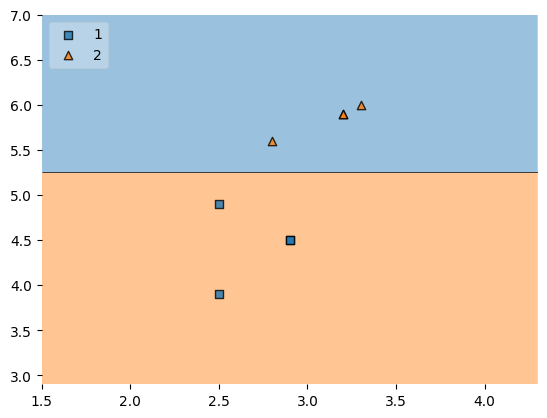

In [95]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [96]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [97]:
df_test

,SepalWidthCm,PetalLengthCm,Species
87,2.3,4.4,1
99,2.8,4.1,1
128,2.8,5.6,2
73,2.8,4.7,1
93,2.3,3.3,1


In [98]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\divya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [99]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
104,3.0,5.8,2
100,3.3,6.0,2
143,3.2,5.9,2
132,2.8,5.6,2
83,2.7,5.1,1
69,2.5,3.9,1
118,2.6,6.9,2
129,3.0,5.8,2
78,2.9,4.5,1


In [100]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
78,2.9,4.5,1
143,3.2,5.9,2
69,2.5,3.9,1
104,3.0,5.8,2
118,2.6,6.9,2
100,3.3,6.0,2
132,2.8,5.6,2
83,2.7,5.1,1


# Random Subspaces

In [101]:
df1 = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\Iris.csv")
df1 = df1.sample(10)

In [102]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
107,108,7.3,2.9,6.3,1.8,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
114,115,5.8,2.8,5.1,2.4,Iris-virginica
113,114,5.7,2.5,5.0,2.0,Iris-virginica
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
122,123,7.7,2.8,6.7,2.0,Iris-virginica


In [103]:
df1.sample(2,replace=True,axis=1)

,Id,Species
96,97,Iris-versicolor
107,108,Iris-virginica
109,110,Iris-virginica
133,134,Iris-virginica
12,13,Iris-setosa
85,86,Iris-versicolor
114,115,Iris-virginica
113,114,Iris-virginica
72,73,Iris-versicolor
122,123,Iris-virginica


# Random Patches

In [104]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
107,108,7.3,2.9,6.3,1.8,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
133,134,6.3,2.8,5.1,1.5,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
114,115,5.8,2.8,5.1,2.4,Iris-virginica
113,114,5.7,2.5,5.0,2.0,Iris-virginica
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
122,123,7.7,2.8,6.7,2.0,Iris-virginica


In [105]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,Species,PetalLengthCm
109,Iris-virginica,6.1
113,Iris-virginica,5.0
133,Iris-virginica,5.1
85,Iris-versicolor,4.5
113,Iris-virginica,5.0
122,Iris-virginica,6.7
96,Iris-versicolor,4.2
133,Iris-virginica,5.1


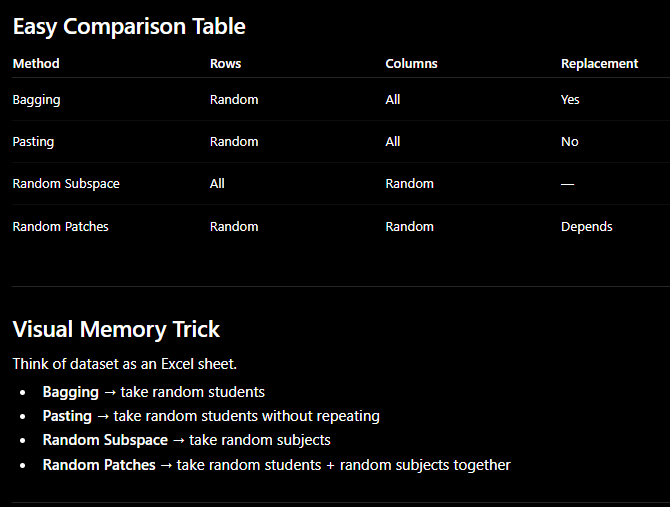

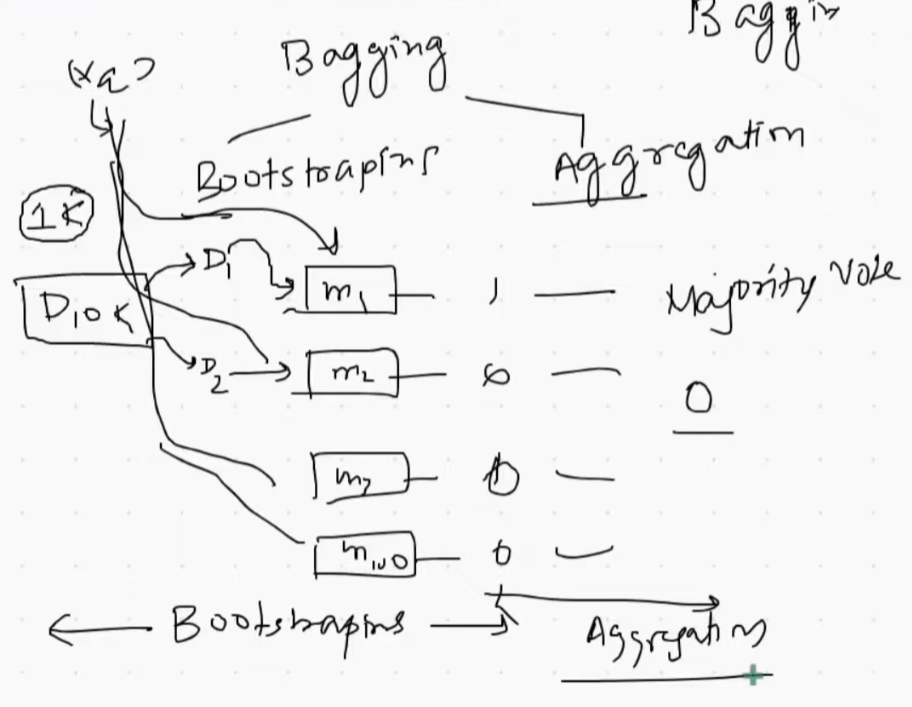
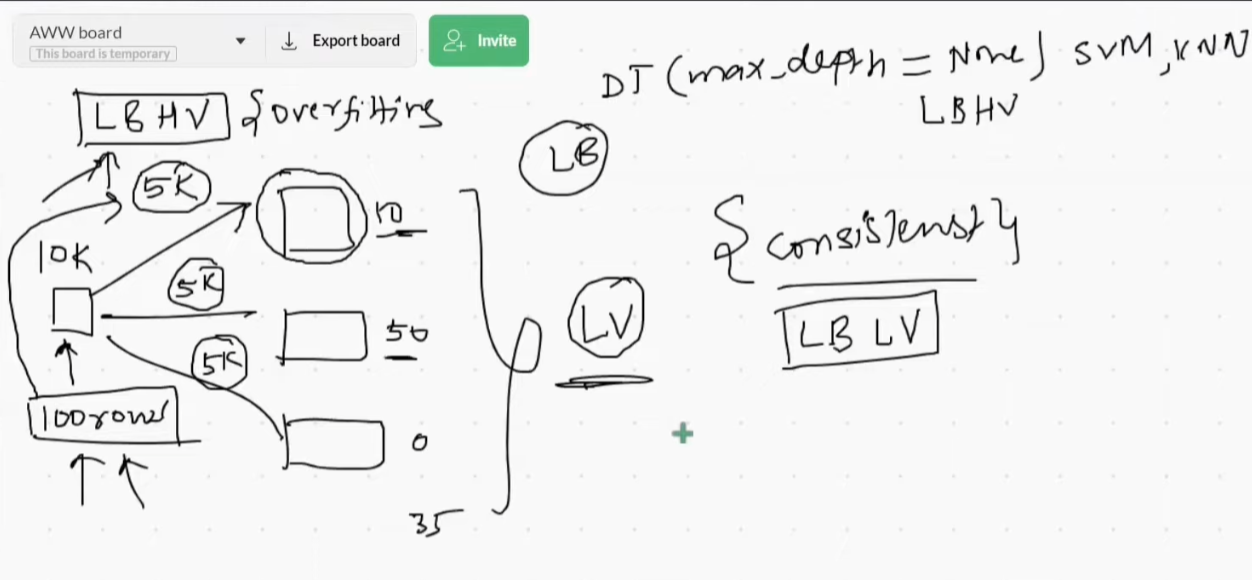

In [106]:
#ENSEMBLE LEARNING

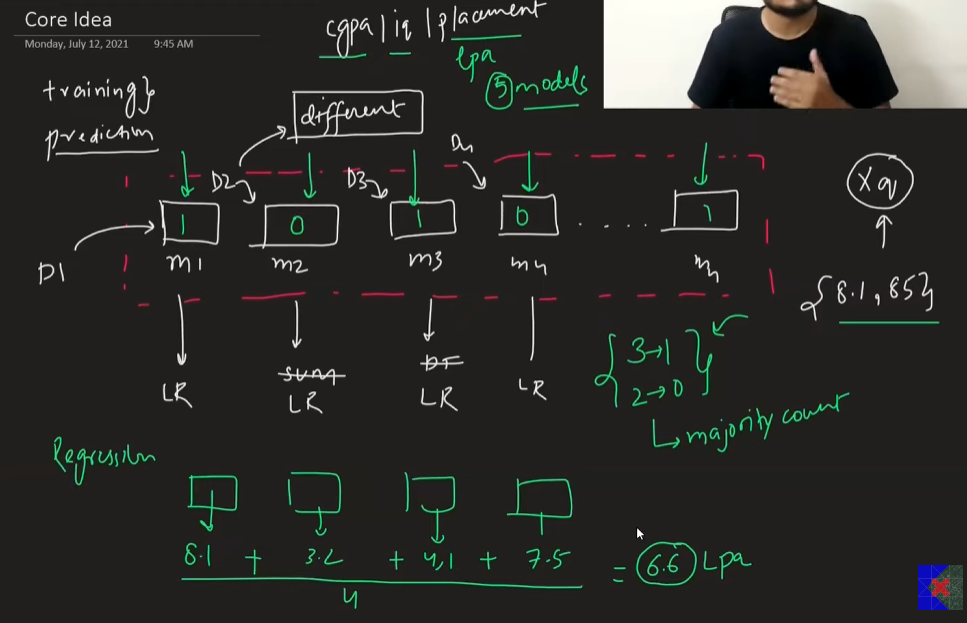
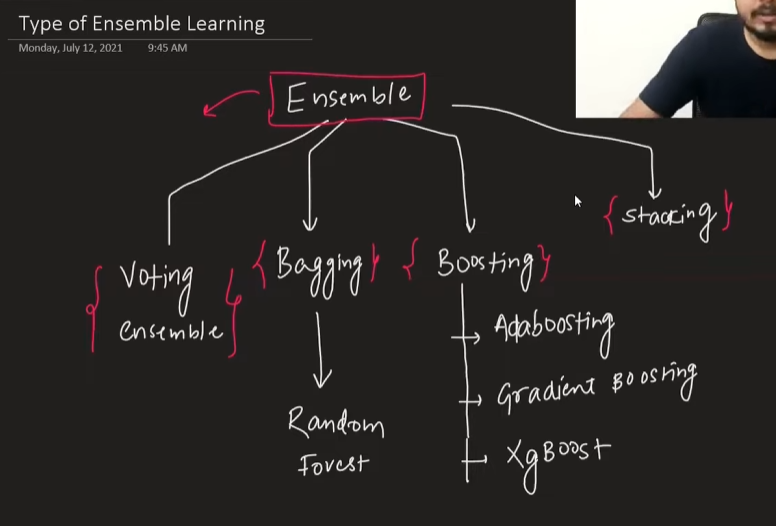
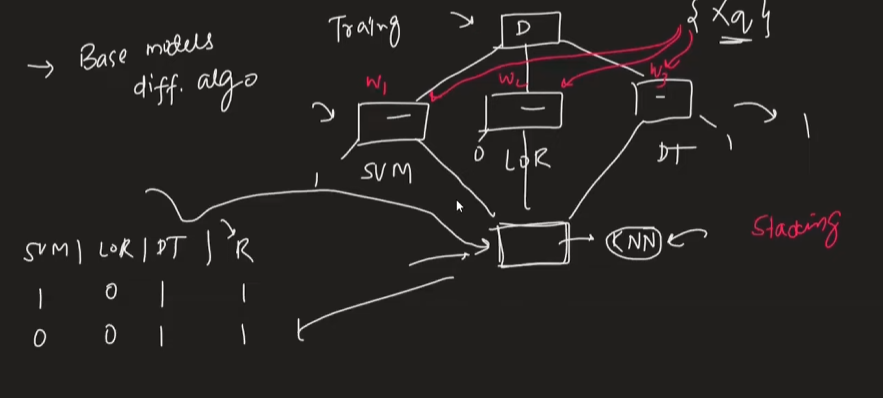
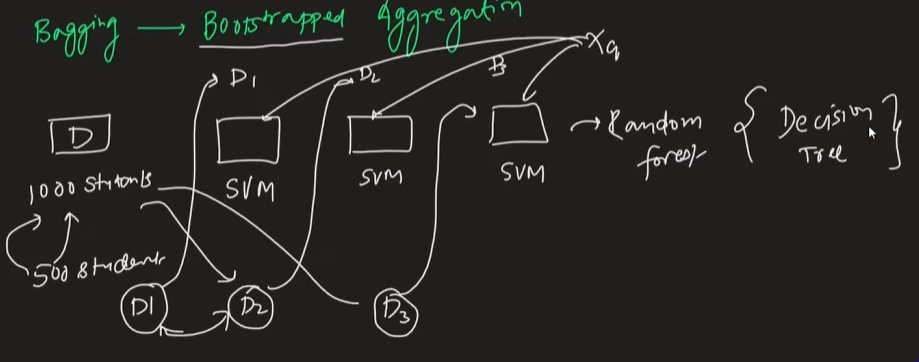
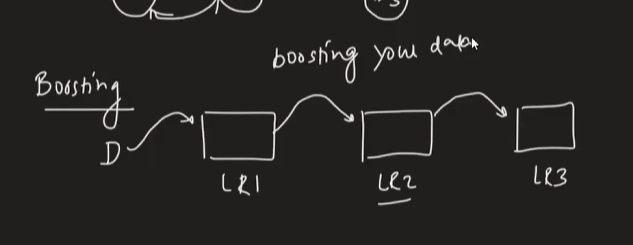
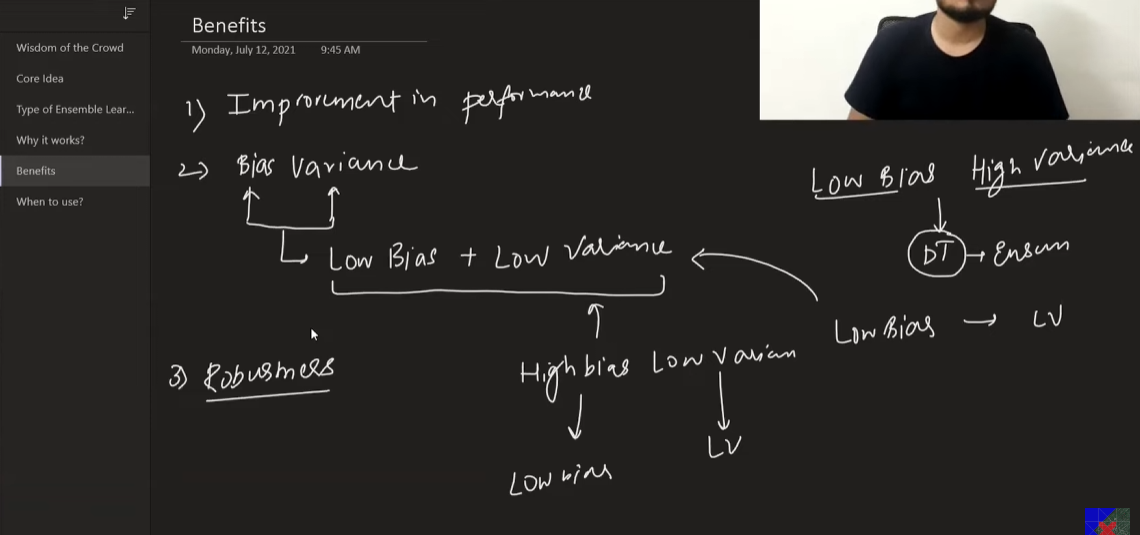